In [131]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from feature_analysis import FeatureDistributionPlotter
from feature_engine.selection import DropHighPSIFeatures
from phik import report  # also registers the df.phik_matrix() pandas extension


#### Configuration

In [ ]:
# ── Random state ──────────────────────────────────────────────────────────────
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# ── Dataset generation ─────────────────────────────────────────────────────────
NUM_SAMPLES            = 1_000
NUM_NUMERIC_FEATURES   = 5
NUM_CATEGORICAL_FEATURES = 3

# Non-linear feature: y = exp(NL_SCALE * x + noise)
# exp() is strictly monotonic  →  Spearman ≈ 1.0
# but exponentially non-linear →  Pearson  ≪ 1.0
# Raise NL_SCALE to widen the gap further.
NL_SCALE     = 2    # exponential growth rate
NL_NOISE_STD = 0.1  # injected into the exponent (multiplicative noise)

# ── Train / test split ─────────────────────────────────────────────────────────
TRAIN_SIZE = 0.8

# ── PSI ────────────────────────────────────────────────────────────────────────
PSI_THRESHOLD        = 0.25
PSI_SHIFT_MULTIPLIER = 10_000_000

# ── PhiK correlation report ────────────────────────────────────────────────────
PHIK_SIGNIFICANCE_THRESHOLD = 3
PHIK_CORRELATION_THRESHOLD  = 0.5

# ── High-Pearson / Low-Spearman feature ──────────────────────────────────────
# y = x + NL2_BUMP_AMP * exp(-x^2 / NL2_BUMP_WIDTH) + noise
# A Gaussian bump centred at x=0 inflates y for typical (middle) x values above
# where large-x values land, creating rank inversions near the centre.
# Extreme (x, y) pairs stay linear → Pearson stays up.
NL2_BUMP_AMP   = 2.0  # bump height; raise to widen the Pearson / Spearman gap
NL2_BUMP_WIDTH = 0.5  # controls how wide the bump is (variance of the Gaussian)
NL2_NOISE_STD  = 0.3  # additive noise

# ── Section 4: choosing among correlated features ─────────────────────────────
# Three versions of the same underlying signal, with increasing noise.
# v1 is cleanest (highest target correlation) but will be drifted.
CG_RANDOM_SEED = 2024  # isolated seed so CG generation is independent of prior state
CG_NOISE_V1   = 0.28  
CG_NOISE_V2   = 0.34  
CG_NOISE_V3   = 0.35  
CG_DRIFT_MEAN = 0.4 

#### 1. Generate random numeric features

In [133]:
numeric_features = pd.DataFrame(
    np.random.randn(NUM_SAMPLES, NUM_NUMERIC_FEATURES),
    columns=[f'num_feature_{i+1}' for i in range(NUM_NUMERIC_FEATURES)],
)

#### 2. Generate a few categorical features

In [134]:
categorical_data = {
    f'cat_feature_{i+1}': np.random.choice(['A', 'B', 'C', 'D'], size=NUM_SAMPLES)
    for i in range(NUM_CATEGORICAL_FEATURES)
}
categorical_features = pd.DataFrame(categorical_data)

#### 3. Generate a binary label
Let's make the label somewhat dependent on some numeric and categorical features

In [135]:
label = (
    0.3 * numeric_features['num_feature_1']
    + 0.5 * numeric_features['num_feature_2']
    + (categorical_features['cat_feature_1'] == 'A').astype(int) * 0.8
    + np.random.randn(NUM_SAMPLES) * 0.5
    > 0.5
).astype(int)

#### 4. Create a non-linear but monotonic feature
`num_feature_nonlinear_corr = exp(NL_SCALE · x + noise)` is **strictly monotonic** (every rank is preserved → Spearman ≈ 1), yet **exponentially non-linear** (the linear fit is poor → Pearson ≪ 1). This maximises the gap between the two metrics, making it clearly visible in the scatter plot.

In [136]:
x = numeric_features['num_feature_1']
num_feature_nonlinear_corr = np.exp(
    NL_SCALE * x + np.random.randn(NUM_SAMPLES) * NL_NOISE_STD
)

#### 5. Create a feature with high Pearson but lower Spearman
`y = x + NL2_BUMP_AMP · exp(-x² / NL2_BUMP_WIDTH) + noise`

A Gaussian bump centred at x=0 inflates the y values of *typical* (middle) x values above where *extreme* x values land. Because extreme (x, y) pairs remain linear, Pearson — which weights values by their magnitude — stays strong. But many ordinary x values end up with a *higher y rank* than larger x values, creating rank inversions that visibly suppress Spearman. The scatter looks like an almost-linear cloud with a gentle arch.

In [137]:
num_feature_pearson_driven = (
    x
    + NL2_BUMP_AMP * np.exp(-x**2 / NL2_BUMP_WIDTH)
    + np.random.randn(NUM_SAMPLES) * NL2_NOISE_STD
)

#### 6. Create an ad-hoc categorical correlated variable for PhiK
We'll make 'cat_feature_corr' correlated with 'cat_feature_1'

In [138]:
cat_feature_corr = []
for val in categorical_features['cat_feature_1']:
    if val == 'A':
        # High chance of being 'X'
        cat_feature_corr.append(np.random.choice(['X', 'Y', 'Z'], p=[0.7, 0.2, 0.1]))
    elif val == 'B':
        # High chance of being 'Y'
        cat_feature_corr.append(np.random.choice(['X', 'Y', 'Z'], p=[0.1, 0.8, 0.1]))
    else:
        # More random
        cat_feature_corr.append(np.random.choice(['X', 'Y', 'Z'], p=[0.3, 0.3, 0.4]))
cat_feature_corr = pd.Series(cat_feature_corr, name='cat_feature_corr')

#### Combine all features into a single DataFrame

In [139]:
dataset = pd.concat([
    numeric_features,
    categorical_features,
    pd.Series(num_feature_nonlinear_corr, name='num_feature_nonlinear_corr'),
    pd.Series(num_feature_pearson_driven, name='num_feature_pearson_driven'),
    cat_feature_corr,
    pd.Series(label, name='target'),
], axis=1)

dataset.head()

,num_feature_1,num_feature_2,num_feature_3,num_feature_4,num_feature_5,cat_feature_1,cat_feature_2,cat_feature_3,num_feature_nonlinear_corr,num_feature_pearson_driven,cat_feature_corr,target
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,D,C,C,2.590796,1.944857,Y,1
1,-0.234137,1.579213,0.767435,-0.469474,0.542560,A,B,D,0.582338,1.482389,X,1
2,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,D,C,C,0.408448,-0.134218,X,0
3,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,B,C,D,0.313339,0.589560,Y,0
4,1.465649,-0.225776,0.067528,-1.424748,-0.544383,D,A,C,20.171583,1.492339,Z,0


### Let's Split in training and test

In [140]:
n_split       = int(TRAIN_SIZE * len(dataset))
dataset_train = dataset[:n_split]
dataset_test  = dataset[n_split:]

print(f"Train : {dataset_train.shape}  |  positive rate: {dataset_train['target'].mean():.2%}")
print(f"Test  : {dataset_test.shape}   |  positive rate: {dataset_test['target'].mean():.2%}")

Train : (800, 12)  |  positive rate: 36.88%
Test  : (200, 12)   |  positive rate: 35.00%


### Feature Distribution Overview
Before diving into feature elimination, let's visualise how each feature is distributed across the train and test sets. Any feature that looks very different between splits is a candidate for PSI-based removal.

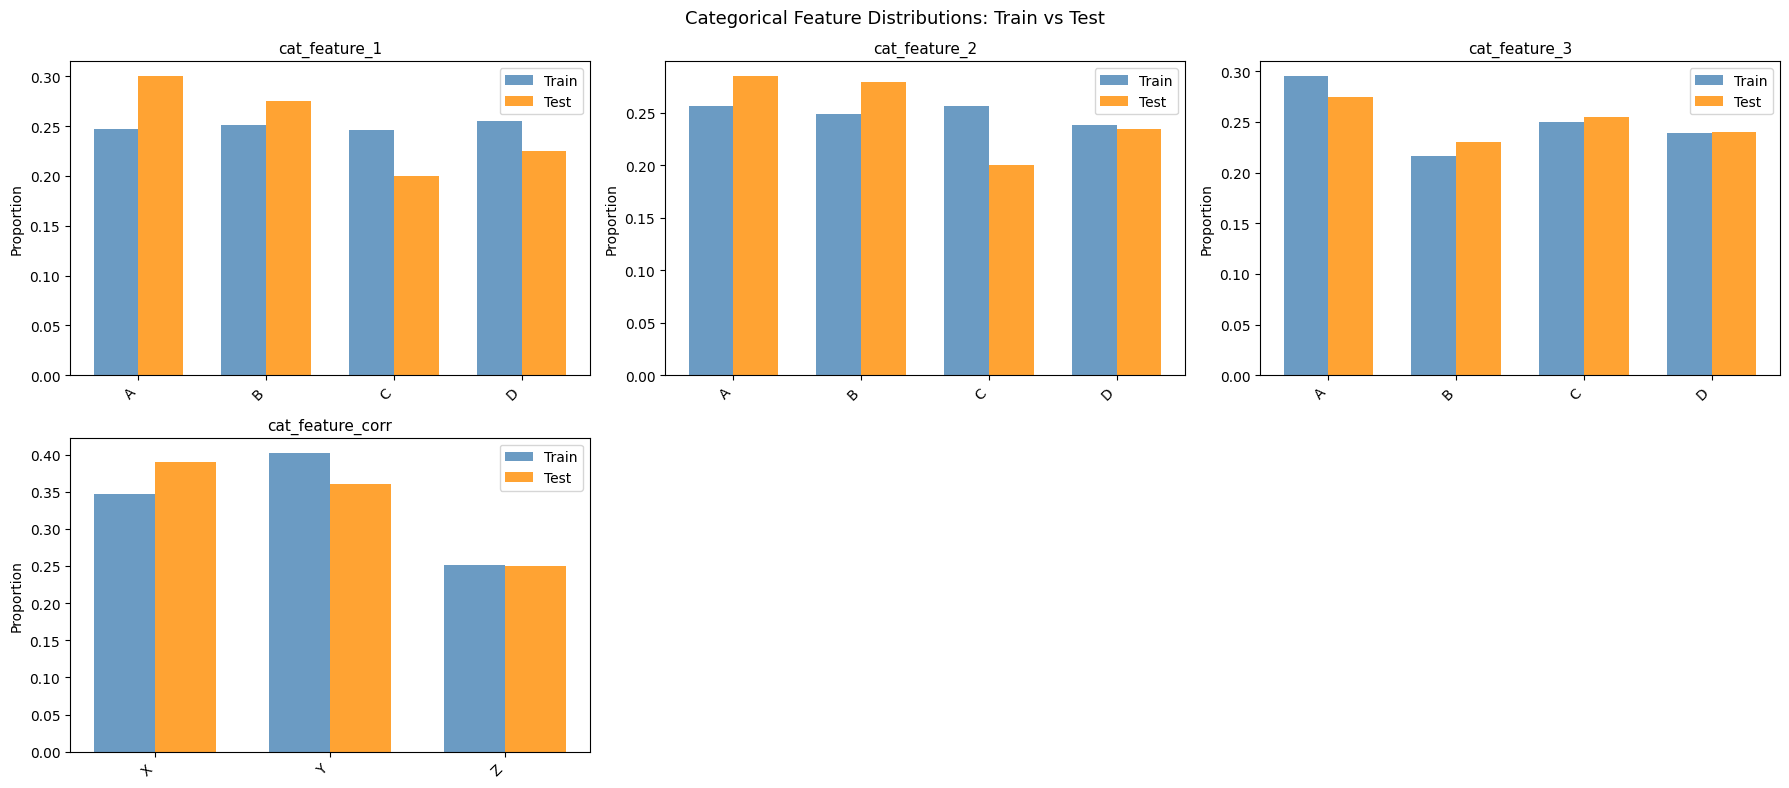

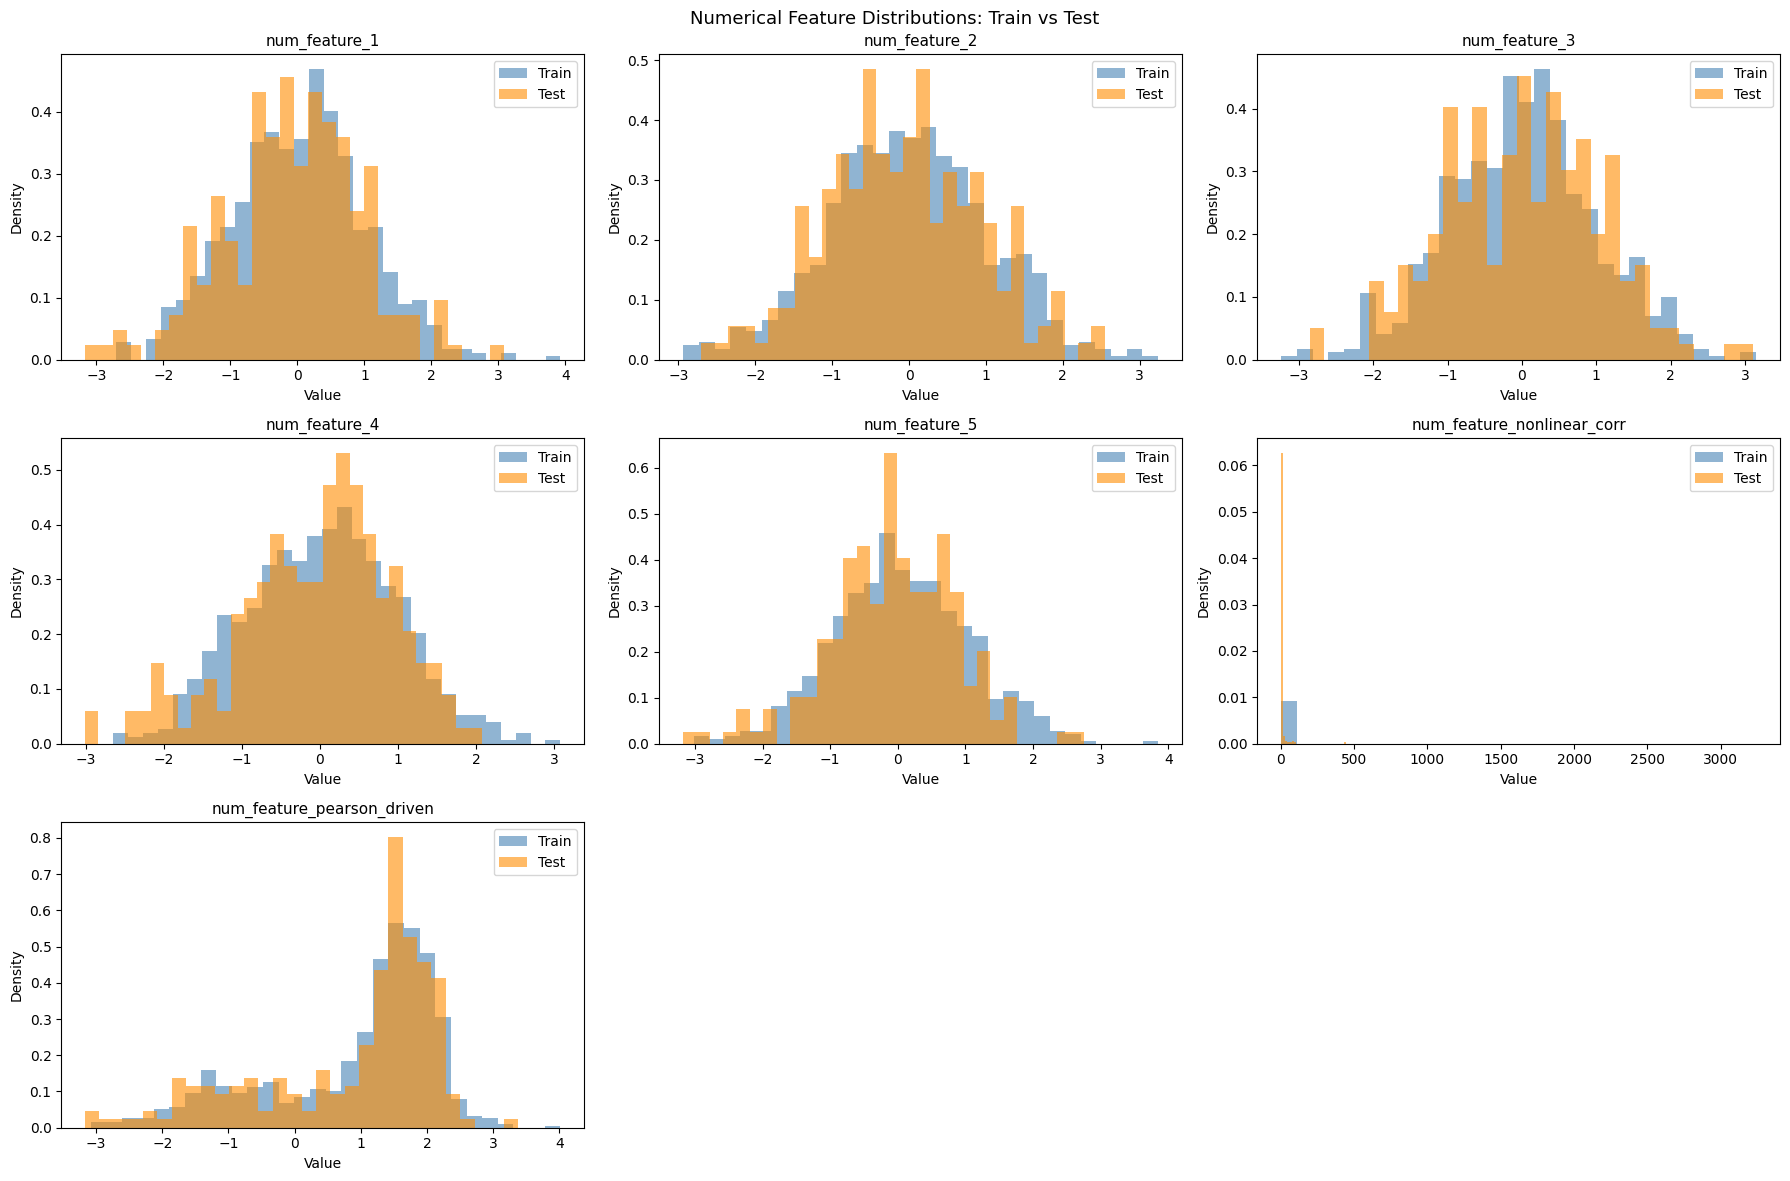

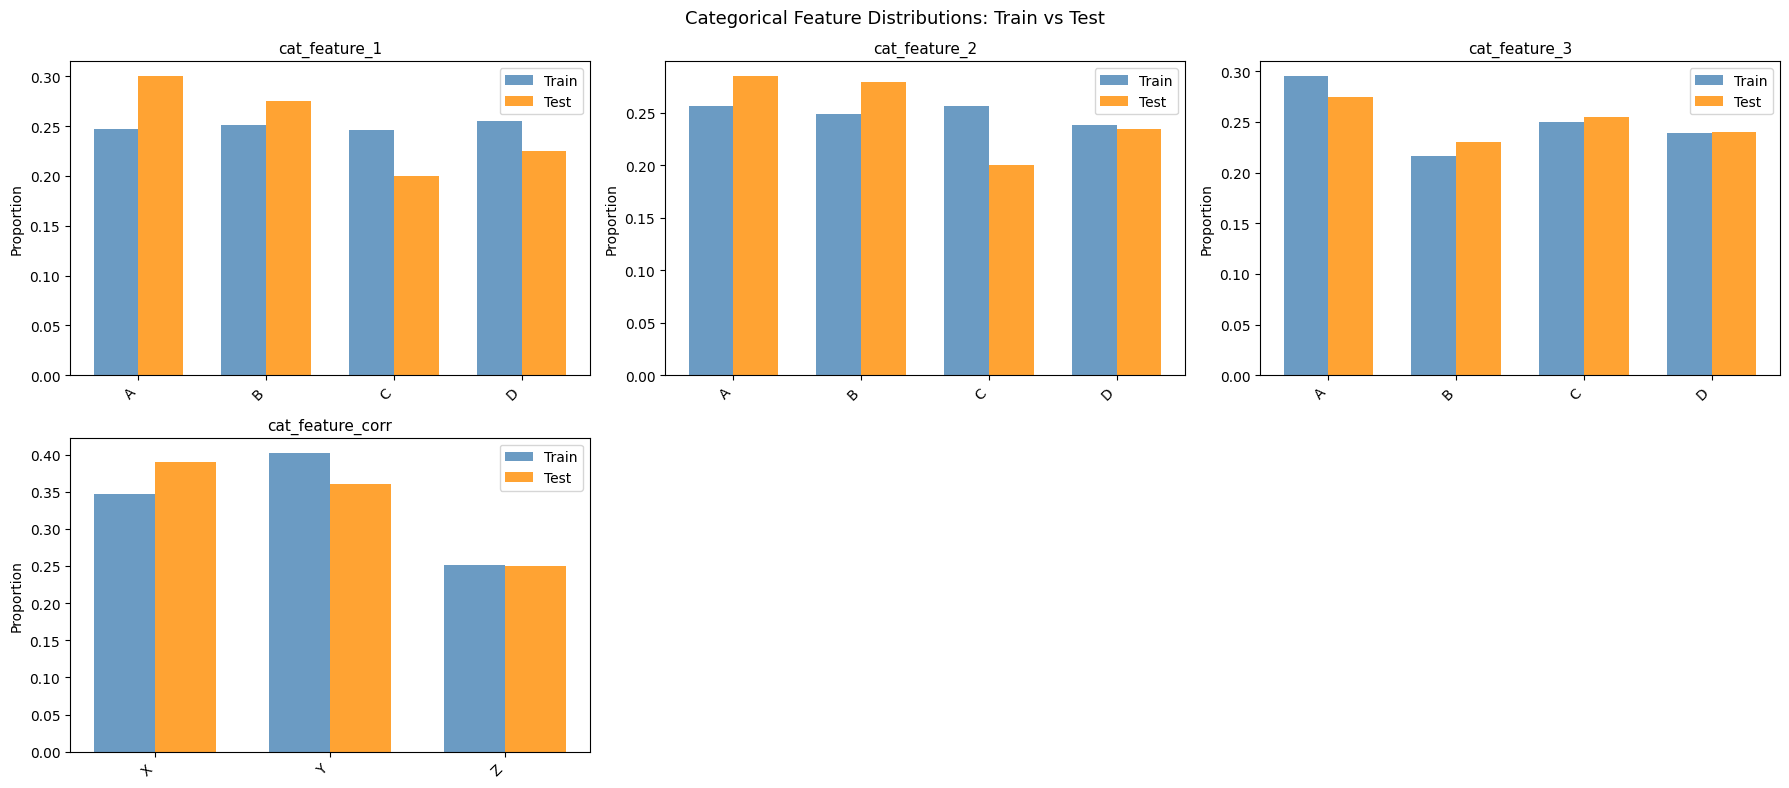

In [141]:
plotter = FeatureDistributionPlotter(dataset_train)

plotter.plot_numerical_distributions(dataset_train, dataset_test)
plotter.plot_categorical_distributions(dataset_train, dataset_test)

#### Let's Apply PSI
* For [PSI I use the feature engine library](https://feature-engine.trainindata.com/en/1.8.x/user_guide/selection/DropHighPSIFeatures.html), I found that a great source for the feature engineering transformation and I suggest to deep dive to other methods if you are not an expert of it

* [Citing their documentation](https://feature-engine.trainindata.com/en/1.8.x/user_guide/selection/DropHighPSIFeatures.html#threshold)
  * I discard a feature if the PSI value is higher than **0.25**
  * If unsure they mention you can also use the `auto` value

* Your dataset must be ordered for your reference date - in my case since I randomly generated everything I considered everything already ordered and I did not need to ensure the time ordering of the dataframe.

In [142]:
drop_psi = DropHighPSIFeatures(
    threshold=PSI_THRESHOLD,
    missing_values='ignore',
    split_frac=TRAIN_SIZE,
)
drop_psi.fit(X=dataset)
features_to_drop_psi = drop_psi.features_to_drop_

print(f"{len(features_to_drop_psi)} features to drop based on PSI > {PSI_THRESHOLD}:")
features_to_drop_psi

0 features to drop based on PSI > 0.25:


[]

#### Interpreting PSI
| PSI value | Interpretation | Action |
|---|---|---|
| < 0.1 | No significant shift | Keep the feature |
| 0.1 – 0.25 | Moderate shift — worth monitoring | Keep, but flag for review |
| > 0.25 | Major shift | **Drop** — the feature behaves differently in train vs test |

With stable synthetic data all features pass. In the next cell we force a distribution shift on `num_feature_2` to show what a real drift looks like.

#### Simulating a distribution shift
In the real world a shift can happen when: the data pipeline changes, the population changes seasonally, or a feature is computed differently in production. Here we multiply the training values of `num_feature_2` by a large constant to mimic an abrupt upstream change.

In [143]:
dataset.loc[:n_split - 1, "num_feature_2"] = (
    PSI_SHIFT_MULTIPLIER * dataset.loc[:n_split - 1, "num_feature_2"]
)

In [144]:
drop_psi = DropHighPSIFeatures(
    threshold=PSI_THRESHOLD, # "auto" can be used here if you prefer to let them decide
    missing_values='ignore',
    split_frac=TRAIN_SIZE
)
drop_psi.fit(X=dataset)

features_to_drop_psi = drop_psi.features_to_drop_

print(f"{len(features_to_drop_psi)} features to drop based on PSI > {PSI_THRESHOLD}:")

features_to_drop_psi

1 features to drop based on PSI > 0.25:


['num_feature_2']

In [145]:
drop_psi.psi_values_

{'num_feature_1': np.float64(0.06948409289085317),
 'num_feature_2': np.float64(8.283089355027482),
 'num_feature_3': np.float64(0.06408268277207117),
 'num_feature_4': np.float64(0.030765537922726228),
 'num_feature_5': np.float64(0.09055803954488664),
 'num_feature_nonlinear_corr': np.float64(0.03223870631680055),
 'num_feature_pearson_driven': np.float64(0.04543806018290241),
 'target': np.float64(0.0)}

#### Decision: drop `num_feature_2`
`num_feature_2` now has PSI >> 0.25, meaning its distribution in the training window is completely different from the test window. Any model trained on this feature would learn a pattern that does not exist in production — a textbook case for PSI-based removal.

The remaining features all have PSI < 0.1, so they are safe to keep.

### Applying numerical correlation
* Using pandas is simply as calling just one function if you prefer having everything in a pipeline you can concatenate things and use another [feature engine pipeline step](https://feature-engine.trainindata.com/en/latest/user_guide/selection/DropCorrelatedFeatures.html)

In [146]:
num_cols = plotter.num_cols
num_cols

['num_feature_1',
 'num_feature_2',
 'num_feature_3',
 'num_feature_4',
 'num_feature_5',
 'num_feature_nonlinear_corr',
 'num_feature_pearson_driven']

#### What to look for in the heatmap
Flag any pair with **|r| > 0.9** (strict threshold) or **|r| > 0.7** (lenient).

| Scenario | Which metric | Decision |
|---|---|---|
| Linear model (Logistic Regression, Linear Regression) | **Pearson** | Drop one feature of any highly-linearly-correlated pair to reduce multicollinearity |
| Tree-based model (Random Forest, GBM) | **Spearman** | Drop one feature of any highly-monotonically-correlated pair — trees are immune to linear collinearity but redundant monotonic features still slow training and hurt interpretability |

In our dataset: `num_feature_nonlinear_corr` is **highly Spearman-correlated** with `num_feature_1` (monotonic exp relationship) but **low Pearson** — a linear model would keep both, while a tree-based screen would drop one. `num_feature_pearson_driven` shows the opposite: **high Pearson**, lower Spearman — a linear model screen would catch it, a Spearman-only screen would miss it.

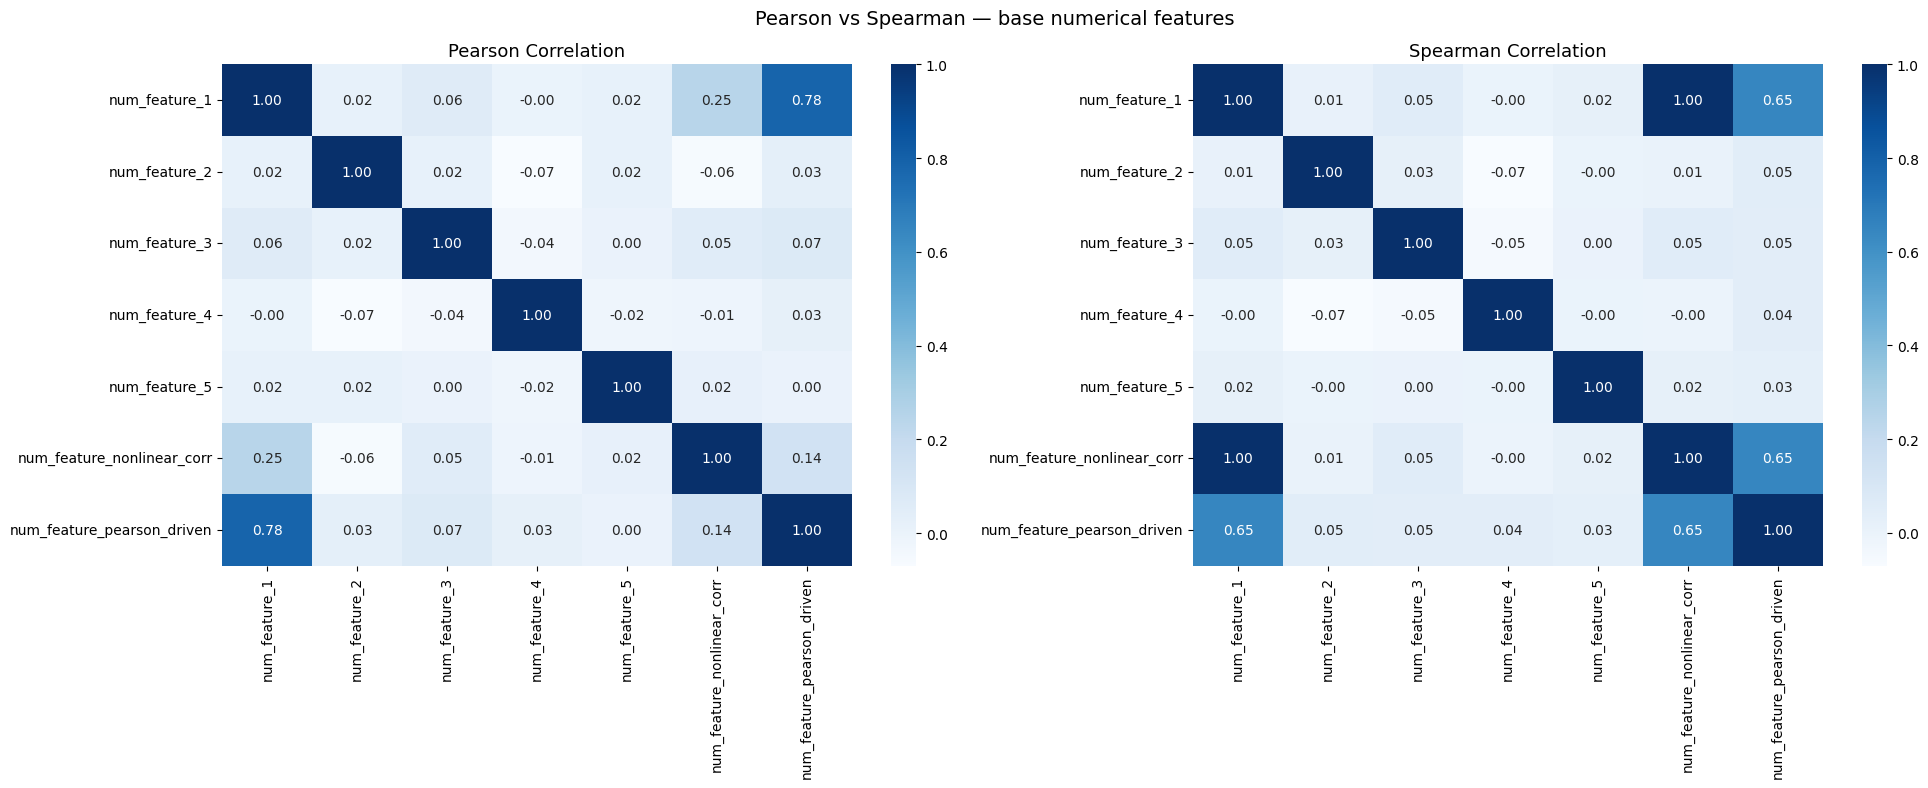

In [147]:
pearson_corr  = dataset_train[num_cols].corr(method='pearson')
spearman_corr = dataset_train[num_cols].corr(method='spearman')

_ = plotter.plot_comparison_heatmaps(
    pearson_corr,
    spearman_corr,
    title_a='Pearson Correlation',
    title_b='Spearman Correlation',
    suptitle='Pearson vs Spearman — base numerical features',
)

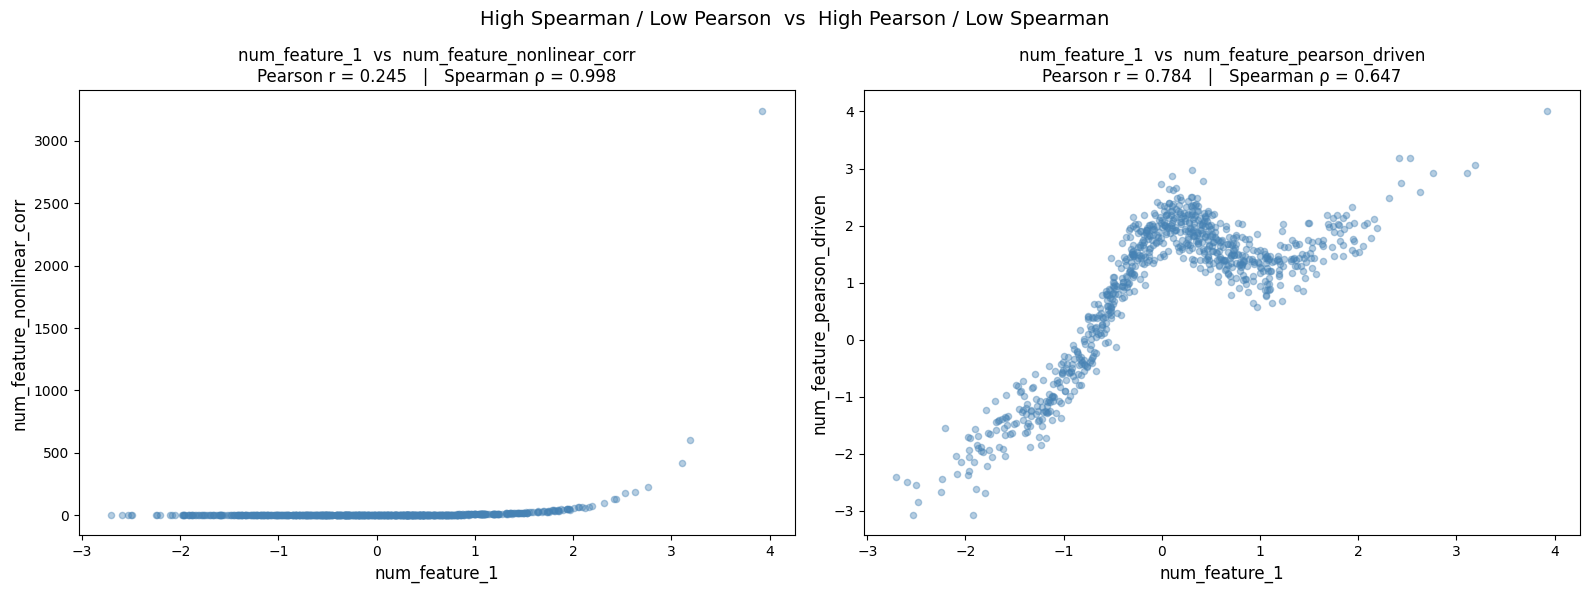

In [148]:
_ = plotter.plot_scatter_comparison(
    dataset_train,
    pairs=[
        ('num_feature_1', 'num_feature_nonlinear_corr'),
        ('num_feature_1', 'num_feature_pearson_driven'),
    ],
    suptitle='High Spearman / Low Pearson  vs  High Pearson / Low Spearman',
)

#### Reading the scatter plots
**Left — high Spearman, low Pearson** (`num_feature_nonlinear_corr`): the hockey-stick shape means every rank is respected (monotonic) but the linear fit is poor. A Spearman screen catches this; Pearson misses it.

**Right — high Pearson, lower Spearman** (`num_feature_pearson_driven`): the scatter looks almost linear with a subtle arch. A few rank inversions near the centre suppress Spearman while Pearson stays strong because the extreme (x, y) pairs dominate the covariance sum.

> **Rule of thumb:** use Pearson to screen for linear models; use Spearman for tree-based models — and compare both to catch edge cases like these.

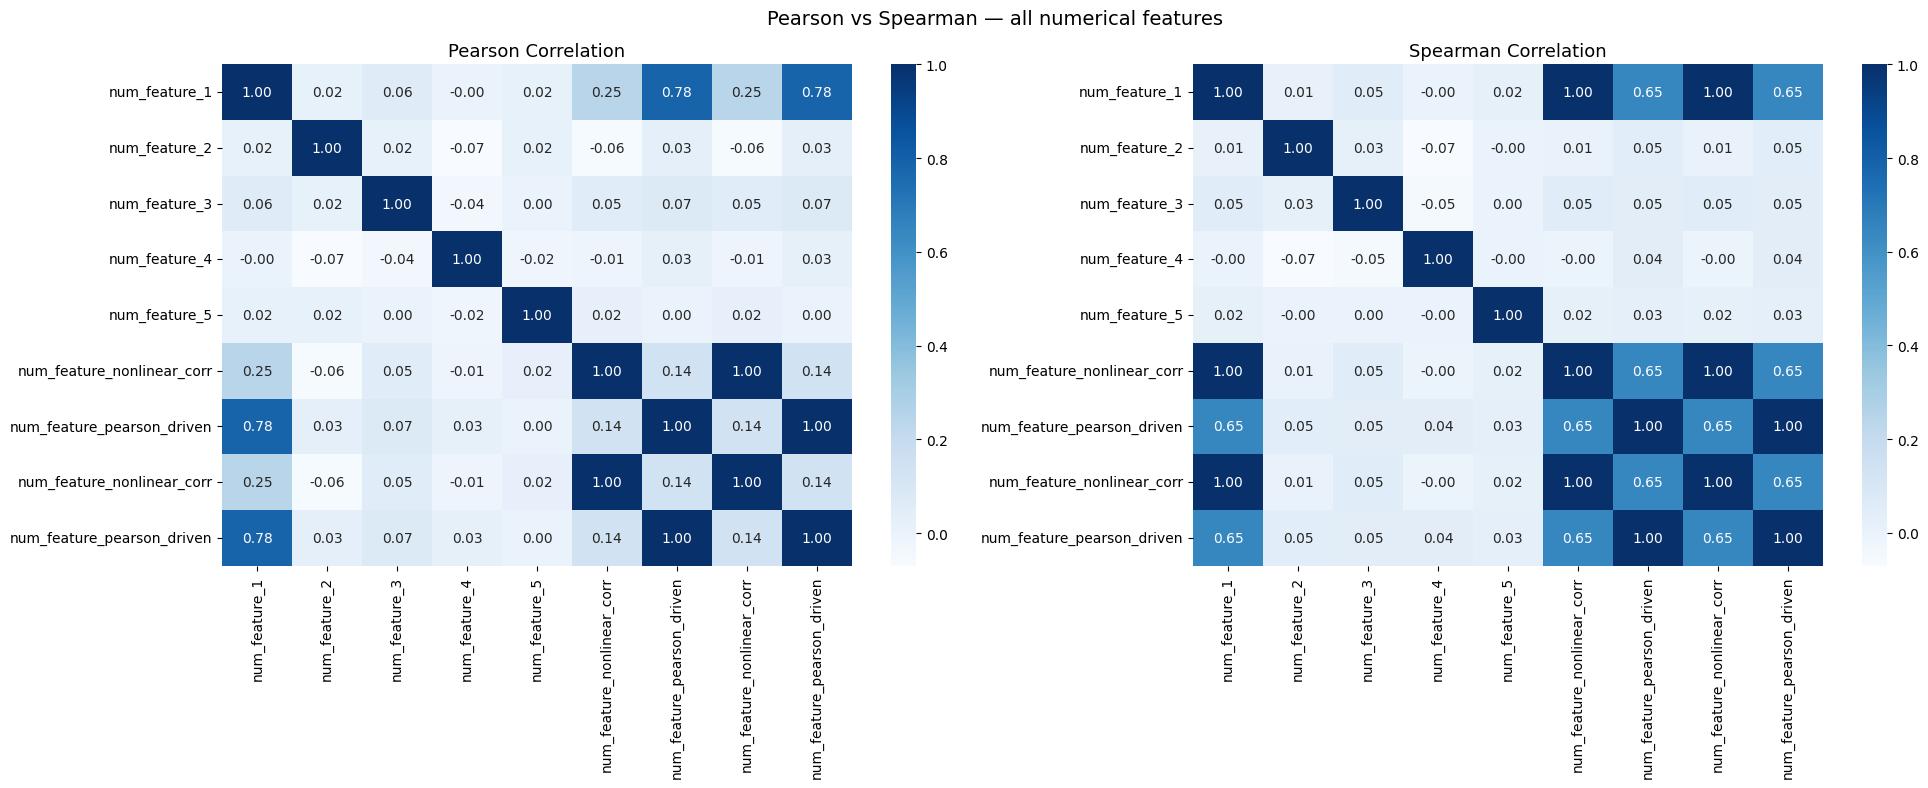

In [149]:
# Include the two engineered features so the contrast shows clearly in the heatmap
new_corr_feat = ['num_feature_nonlinear_corr', 'num_feature_pearson_driven']
pearson_corr  = dataset_train[num_cols + new_corr_feat].corr(method='pearson')
spearman_corr = dataset_train[num_cols + new_corr_feat].corr(method='spearman')

_ = plotter.plot_comparison_heatmaps(
    pearson_corr,
    spearman_corr,
    title_a='Pearson Correlation',
    title_b='Spearman Correlation',
    suptitle='Pearson vs Spearman — all numerical features',
)

#### It is easy to notice how the highest correlation in the matrix differs for spearman and pearson

Reference: [PhiK tutorial notebook](https://colab.research.google.com/github/KaveIO/PhiK/blob/master/phik/notebooks/phik_tutorial_basic.ipynb)

In [150]:
interval_cols = plotter.num_cols

phik_overview = dataset_train.phik_matrix(interval_cols=interval_cols, dropna=True)
phik_overview

,num_feature_1,num_feature_2,num_feature_3,num_feature_4,num_feature_5,cat_feature_1,cat_feature_2,cat_feature_3,num_feature_nonlinear_corr,num_feature_pearson_driven,cat_feature_corr,target
num_feature_1,1.000000,0.190872,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.906639,0.938620,0.000000,0.373460
num_feature_2,0.190872,1.000000,0.166126,0.000000,0.000000,0.000000,0.060337,0.000000,0.171565,0.156667,0.000000,0.611912
num_feature_3,0.000000,0.166126,1.000000,0.000000,0.000000,0.000000,0.047430,0.000000,0.000000,0.081821,0.000000,0.000000
num_feature_4,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.145558,0.126084,0.000000
num_feature_5,0.000000,0.000000,0.000000,0.000000,1.000000,0.133209,0.000000,0.000000,0.000000,0.000000,0.118238,0.079923
cat_feature_1,0.000000,0.000000,0.000000,0.000000,0.133209,1.000000,0.120540,0.118977,0.000000,0.000000,0.435553,0.518736
cat_feature_2,0.000000,0.060337,0.047430,0.000000,0.000000,0.120540,1.000000,0.000000,0.000000,0.000000,0.017666,0.083154
cat_feature_3,0.000000,0.000000,0.000000,0.000000,0.000000,0.118977,0.000000,1.000000,0.000000,0.000000,0.000000,0.101403
num_feature_nonlinear_corr,0.906639,0.171565,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.842474,0.000000,0.030244
num_feature_pearson_driven,0.938620,0.156667,0.081821,0.145558,0.000000,0.000000,0.000000,0.000000,0.842474,1.000000,0.000000,0.256203


### Are all the correlation significant?
* The Phik provides also the significance of the correlation, to avoid dropping features highly correlated if not significantly.

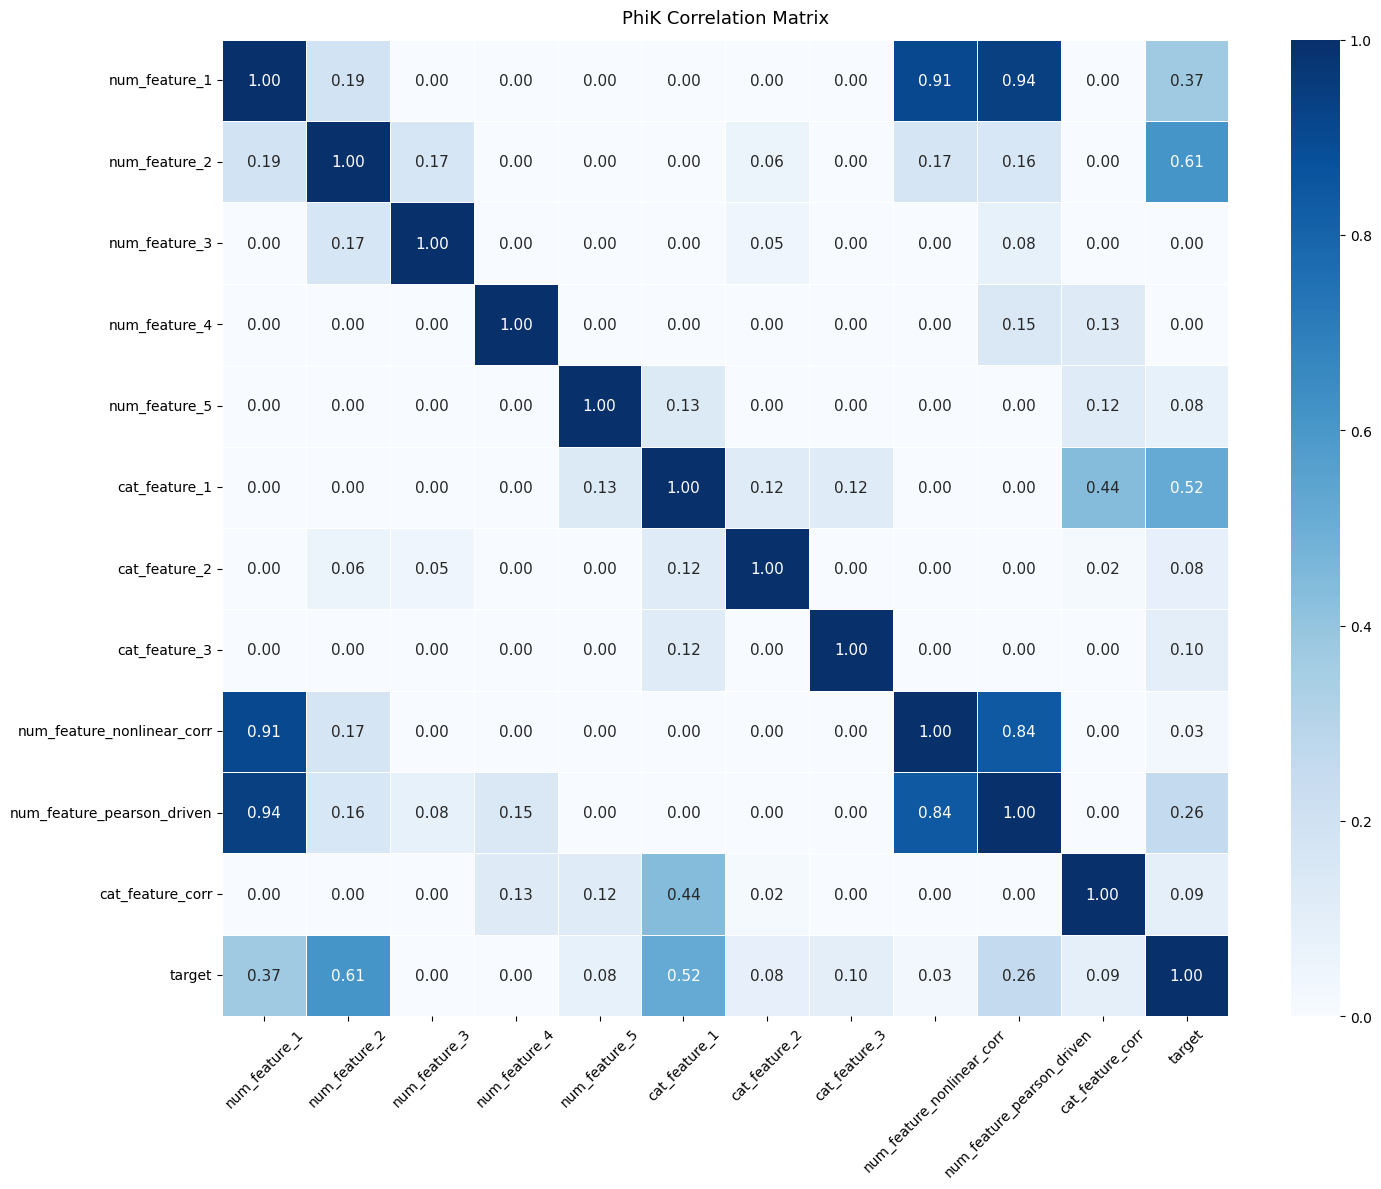

In [151]:
_ = plotter.plot_phik_heatmap(
    phik_overview,
    title="PhiK Correlation Matrix",
    figsize=(15, 12),
)

#### What to look for in the PhiK heatmap
PhiK ranges from 0 (no association) to 1 (perfect association) for **any** feature type (numerical, categorical, or mixed).

| PhiK value | Interpretation |
|---|---|
| < 0.15 | Negligible association |
| 0.15 – 0.5 | Moderate — worth investigating |
| > 0.5 | Strong — consider dropping one of the pair |

In our dataset:
- `cat_feature_corr` ↔ `cat_feature_1`: PhiK ≈ 0.41 — moderate, expected since `cat_feature_corr` was constructed to depend on `cat_feature_1`.
- `num_feature_2` ↔ `target`: PhiK ≈ 0.61 — strong signal, this is a genuinely predictive feature (not a redundancy to remove).

> Always cross-check correlation with **significance** (next cell) before dropping — a high PhiK on a small sample can be spurious.

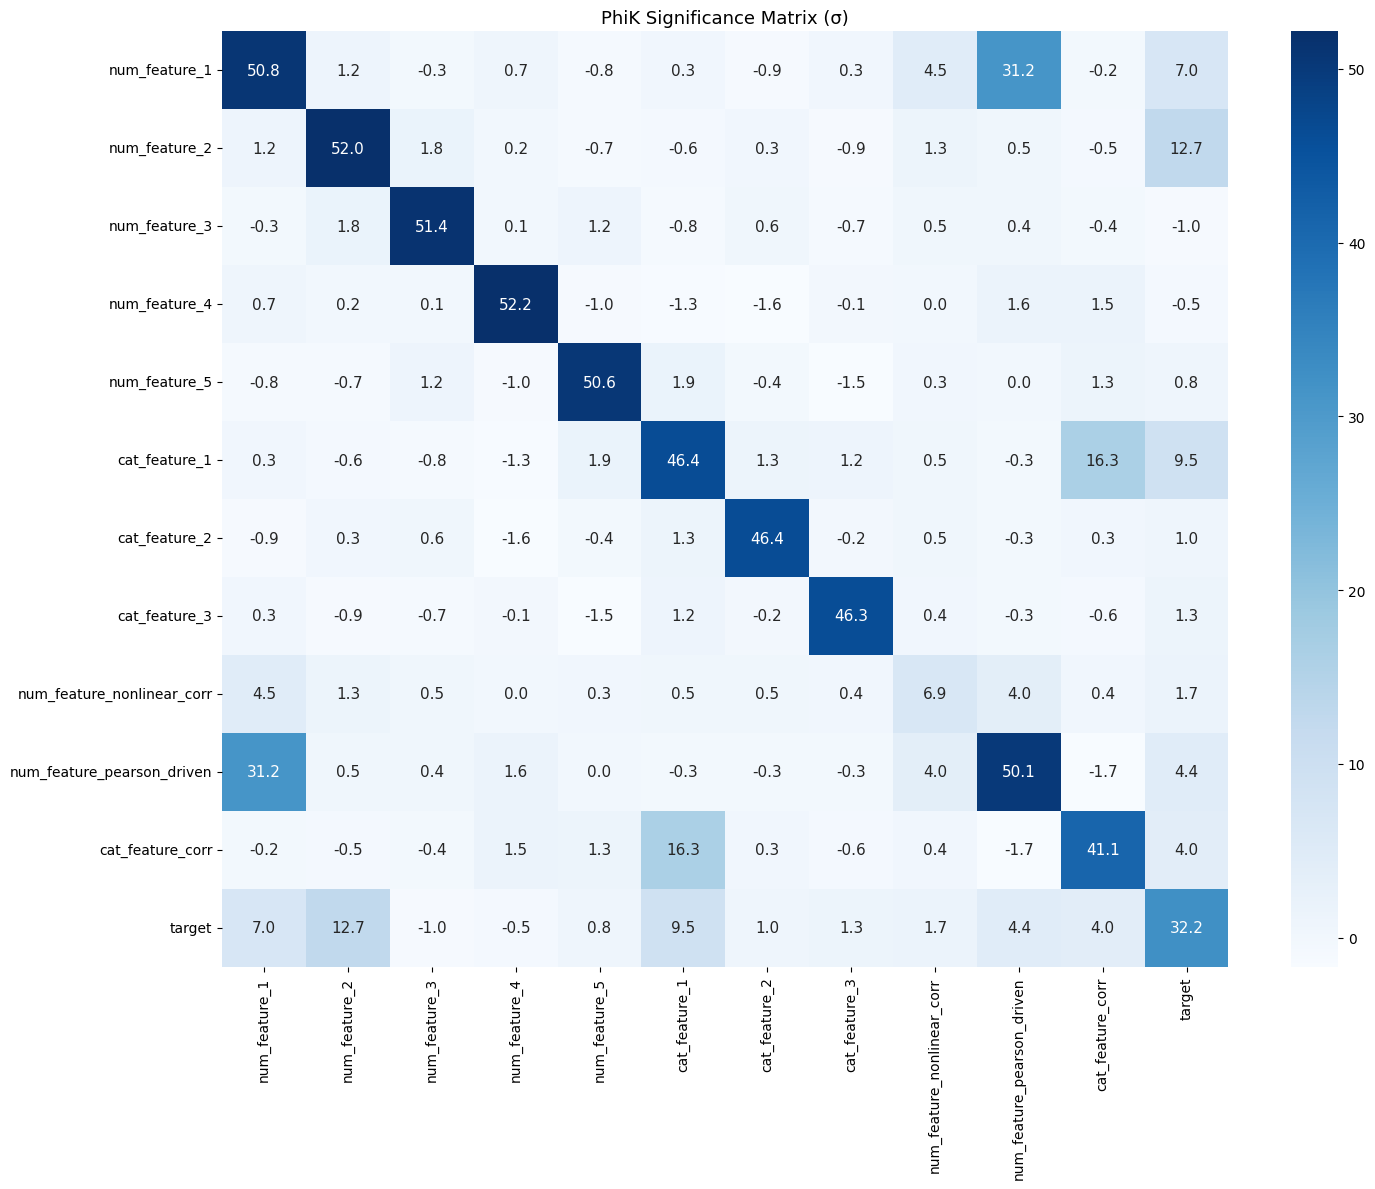

In [152]:
significance_overview = dataset_train.significance_matrix(interval_cols=interval_cols)

_ = plotter.plot_correlation_heatmap(
    significance_overview,
    title="PhiK Significance Matrix (σ)",
    figsize=(15, 12),
    fmt=".1f",
)

---
## 4. Putting it all together: choosing among correlated features

Everything so far has been about identifying redundant or unstable features in isolation.
But in practice you often face a subtler problem: **a group of features that all measure
roughly the same thing, and you need to pick one.**

My instinct early in my career was simple, compute the correlation of each feature with
the target and keep the one with the highest value. It must be the most insightful for the classification.
* Straightforward, fast, and (maybe) wrong.

The problem is that when the differences are small, the ranking is essentially noise. A tiny difference in Pearson?Spearman correlation will not meaningfully change any model metric.

What I learned to do instead: **use PSI as a stability tiebreaker**.

> **Better rule:** when target correlations are nearly equal, prefer the feature with the lowest PSI — it is less likely to drift in production.

#### Build a group of three correlated candidates

In [161]:
# All three features share the same base signal (num_feature_1).
# Each version adds a different amount of noise, so they are
# all highly correlated with each other but not identical.
np.random.seed(CG_RANDOM_SEED)
cg_base = dataset['num_feature_1'].values

cg_feat_v1 = cg_base + np.random.randn(NUM_SAMPLES) * CG_NOISE_V1
cg_feat_v2 = cg_base + np.random.randn(NUM_SAMPLES) * CG_NOISE_V2
cg_feat_v3 = cg_base + np.random.randn(NUM_SAMPLES) * CG_NOISE_V3

cg_cols = ['cg_feat_v1', 'cg_feat_v2', 'cg_feat_v3', 'num_feature_1']
cg_dataset = pd.DataFrame({
    'cg_feat_v1': cg_feat_v1,
    'cg_feat_v2': cg_feat_v2,
    'cg_feat_v3': cg_feat_v3,
    'num_feature_1': cg_base,
    'target':     dataset['target'].values,
})

cg_train = cg_dataset.iloc[:n_split]
cg_test  = cg_dataset.iloc[n_split:]

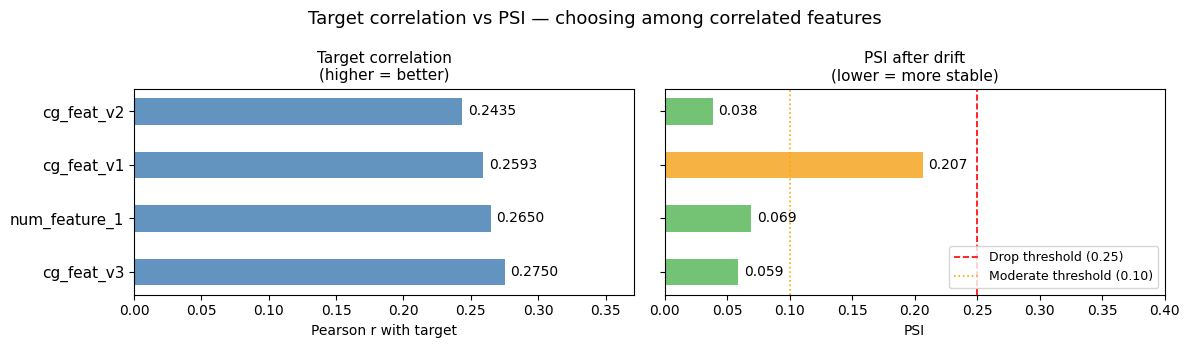

In [162]:
# ── Compute target correlations ───────────────────────────────────────────────
target_corrs = (
    cg_train[cg_cols]
    .corrwith(cg_train['target'])
    .rename('pearson_r')
    .sort_values(ascending=False)
)

# ── Compute PSI after simulated drift on cg_feat_v1 ───────────────────────────
cg_dataset_drifted = cg_dataset.copy()
cg_dataset_drifted.loc[:n_split - 1, 'cg_feat_v1'] += CG_DRIFT_MEAN

drop_psi_cg = DropHighPSIFeatures(threshold=PSI_THRESHOLD, missing_values='ignore', split_frac=TRAIN_SIZE)
drop_psi_cg.fit(cg_dataset_drifted[cg_cols])
psi_values = pd.Series(drop_psi_cg.psi_values_).reindex(target_corrs.index)

# ── Zone colours for PSI bars ─────────────────────────────────────────────────
def psi_colour(v):
    if v > 0.25: return '#e05c5c'   # red   — drop
    if v > 0.10: return '#f5a623'   # amber — moderate
    return '#5cb85c'                # green — stable

psi_colours = [psi_colour(v) for v in psi_values]

# ── Combined figure ───────────────────────────────────────────────────────────
features = target_corrs.index.tolist()   # sorted by target corr descending
y = range(len(features))

fig, (ax_corr, ax_psi) = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
fig.suptitle('Target correlation vs PSI — choosing among correlated features', fontsize=13)

# Left: target correlation
bars = ax_corr.barh(list(y), target_corrs.values, color='steelblue', alpha=0.85, height=0.5)
ax_corr.bar_label(bars, fmt='{:.4f}', padding=4, fontsize=10)
ax_corr.set_xlim(0, target_corrs.max() * 1.35)
ax_corr.set_xlabel('Pearson r with target')
ax_corr.set_title('Target correlation\n(higher = better)', fontsize=11)
ax_corr.set_yticks(list(y))
ax_corr.set_yticklabels(features, fontsize=11)
ax_corr.invert_yaxis()

# Right: PSI — coloured by zone
bars_psi = ax_psi.barh(list(y), psi_values.values, color=psi_colours, alpha=0.85, height=0.5)
ax_psi.bar_label(bars_psi, fmt='{:.3f}', padding=4, fontsize=10)
ax_psi.axvline(PSI_THRESHOLD, color='red',    linestyle='--', linewidth=1.2, label=f'Drop threshold ({PSI_THRESHOLD})')
ax_psi.axvline(0.10,          color='orange', linestyle=':',  linewidth=1.2, label='Moderate threshold (0.10)')
ax_psi.set_xlim(0, max(psi_values.max() * 1.5, PSI_THRESHOLD * 1.6))
ax_psi.set_xlabel('PSI')
ax_psi.set_title('PSI after drift\n(lower = more stable)', fontsize=11)
ax_psi.legend(fontsize=9, loc='lower right')
ax_psi.invert_yaxis()

fig.tight_layout()

#### Decision: keep `cg_feat_v3`

`cg_feat_v2` is more stable, but the drop wrt `cg_feat_v3` is not only 0.01 is around 0.03. In such cases I would consider substantial the difference.
* But, if we had to choose betwen only `cg_feat_v2`  and `cg_feat_v1` I would have chosen the `cg_feat_v2` even if the correlation is lower.

